In [98]:
import torch
import torchvision
from matplotlib.pyplot import imshow
from torchvision import transforms, datasets

train = datasets.MNIST('', train=True, download=True,
                       transform=transforms.Compose([
                           transforms.ToTensor()
                       ]))

test = datasets.MNIST('', train=False, download=True,
                       transform=transforms.Compose([
                           transforms.ToTensor()
                       ]))
trainset = torch.utils.data.DataLoader(train, batch_size=100, shuffle=True)
testset = torch.utils.data.DataLoader(test, batch_size=100, shuffle=False)

In [99]:
import torch.nn as nn
import torch.nn.functional as F


In [100]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1=nn.Linear(28*28, 64)
        self.fc2=nn.Linear(64, 64)
        self.fc3=nn.Linear(64, 64)
        self.fc4=nn.Linear(64, 10)

    def forward(self, x):
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=F.relu(self.fc3(x))
        x=self.fc4(x)
        return F.log_softmax(x, dim=1)






net=Net()
print(net)




Net(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=64, bias=True)
  (fc4): Linear(in_features=64, out_features=10, bias=True)
)


In [101]:

X=torch.rand(28,28)
X=X.view(-1,28*28)

In [102]:

output=net(X)

In [103]:
output

tensor([[-2.2282, -2.3765, -2.1980, -2.3871, -2.3782, -2.3256, -2.2522, -2.2478,
         -2.3566, -2.2976]], grad_fn=<LogSoftmaxBackward0>)

In [104]:
import torch.optim as optim
optimizer=optim.Adam(net.parameters(),lr=0.001)

EPOCHS=3
for epoch in range(EPOCHS):
   for data in trainset:
        X,y=data
        net.zero_grad()
        output=net(X.view(-1,28*28))
        loss=F.nll_loss(output,y)
        loss.backward()
        optimizer.step()
   print(loss)

tensor(0.2956, grad_fn=<NllLossBackward0>)
tensor(0.1316, grad_fn=<NllLossBackward0>)
tensor(0.0818, grad_fn=<NllLossBackward0>)


In [105]:
correct=0
total=0

with torch.no_grad():
    for data in trainset:
        X,y=data
        output=net(X.view(-1,784))
        for idx,i in enumerate(output):
            if torch.argmax(i)==y[idx]:
                correct+=1
            total +=1
print("Accuracy: ",round(correct/total,3))

Accuracy:  0.963


<function matplotlib.pyplot.show(close=None, block=None)>

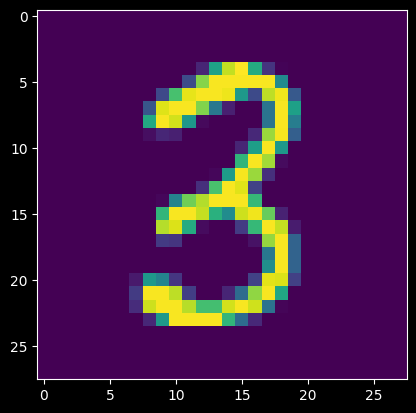

In [106]:
import matplotlib.pyplot as plt
plt.imshow(X[19].view(28,28))
plt.show


In [ ]:
print(torch.argmax(net(X[67].view(-1,784))[0]))
